# Notebook 01 — Exploratory Data Analysis & Multi-Intent Dataset Construction

This notebook:
1. Loads and inspects **MixATIS** and **MixSNIPS**
2. Visualises intent count distribution, top intents/slots, and utterance lengths
3. **Live demo of Algorithm 1**: computes BERT NSP coherence scores to distinguish natural vs. random multi-intent pairs
4. Reproduces the spirit of **Figure 4** from the paper

> **Note**: launch Jupyter with `USE_TF=0 jupyter notebook notebooks/` to avoid a broken TensorFlow installation on this system.

In [2]:
import os, sys
os.environ['USE_TF'] = '0'               
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

import random
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from gemis.data.dataset import bio_to_spans
from gemis.utils.io import load_raw_dataset

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120


In [4]:
ATIS_TRAIN  = Path('../data/raw/mixatis/train.txt')
SNIPS_TRAIN = Path('../data/raw/mixsnips/train.txt')

assert ATIS_TRAIN.exists(),  'Run: python scripts/download_data.py --dataset mixatis  --output data/raw/'
assert SNIPS_TRAIN.exists(), 'Run: python scripts/download_data.py --dataset mixsnips --output data/raw/'

atis  = load_raw_dataset(ATIS_TRAIN)
snips = load_raw_dataset(SNIPS_TRAIN)
print(f'MixATIS  : {len(atis):,} training samples')
print(f'MixSNIPS : {len(snips):,} training samples')

MixATIS  : 13,162 training samples
MixSNIPS : 39,776 training samples


## 1. Sample Inspection

In [5]:
s = atis[0]
words = [t.word for t in s.tokens]
bio   = [t.bio_tag for t in s.tokens]
spans = bio_to_spans(words, bio)

print('Utterance :', ' '.join(words))
print('Intents   :', s.intents)
print('Slot spans:')
for sp in spans:
    print(f'  words[{sp.start}:{sp.end}]  {sp.slot_type:35s} = {words[sp.start:sp.end]}')

Utterance : define airline ua , names of airports and also show me city served both by nationair and canadian airlines international
Intents   : ['atis_abbreviation', 'atis_airport', 'atis_city']
Slot spans:
  words[2:3]  airline_code                        = ['ua']
  words[15:16]  airline_name                        = ['nationair']
  words[17:20]  airline_name                        = ['canadian', 'airlines', 'international']


## 2. Intent Count Distribution

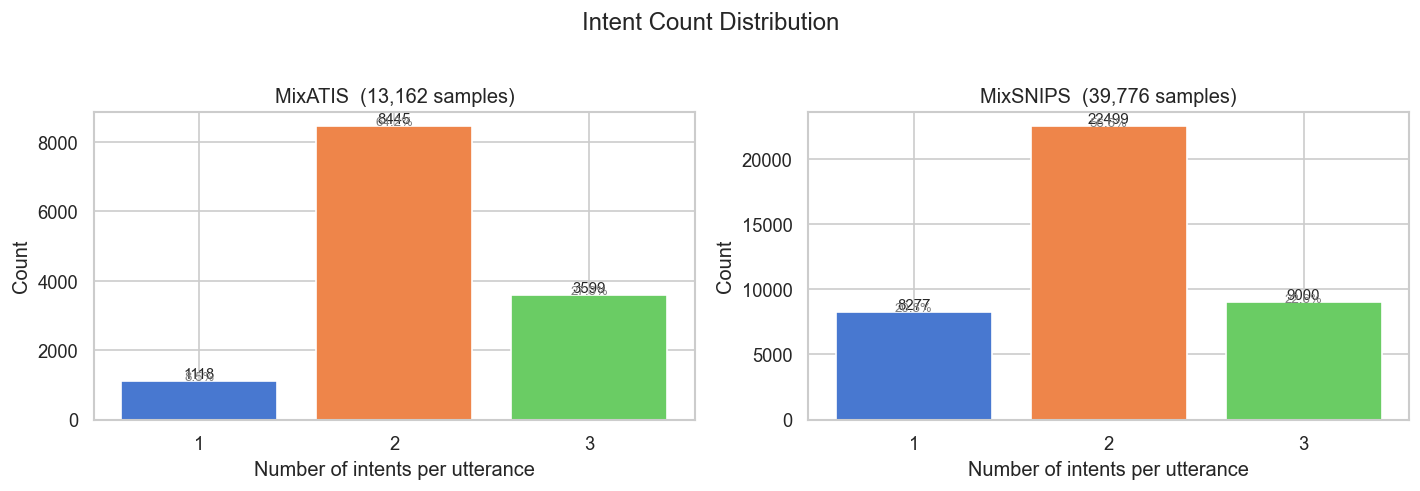

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, samples) in zip(axes, [('MixATIS', atis), ('MixSNIPS', snips)]):
    cnt  = Counter(len(s.intents) for s in samples)
    keys = sorted(cnt)
    vals = [cnt[k] for k in keys]
    bars = ax.bar([str(k) for k in keys], vals, color=sns.color_palette('muted'))
    ax.bar_label(bars, fmt='%d', fontsize=9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
                f'{100*val/len(samples):.1f}%', ha='center', fontsize=8, color='grey')
    ax.set_xlabel('Number of intents per utterance')
    ax.set_ylabel('Count')
    ax.set_title(f'{name}  ({len(samples):,} samples)')

plt.suptitle('Intent Count Distribution', y=1.02)
plt.tight_layout()
plt.show()

## 3. Top Intent Labels

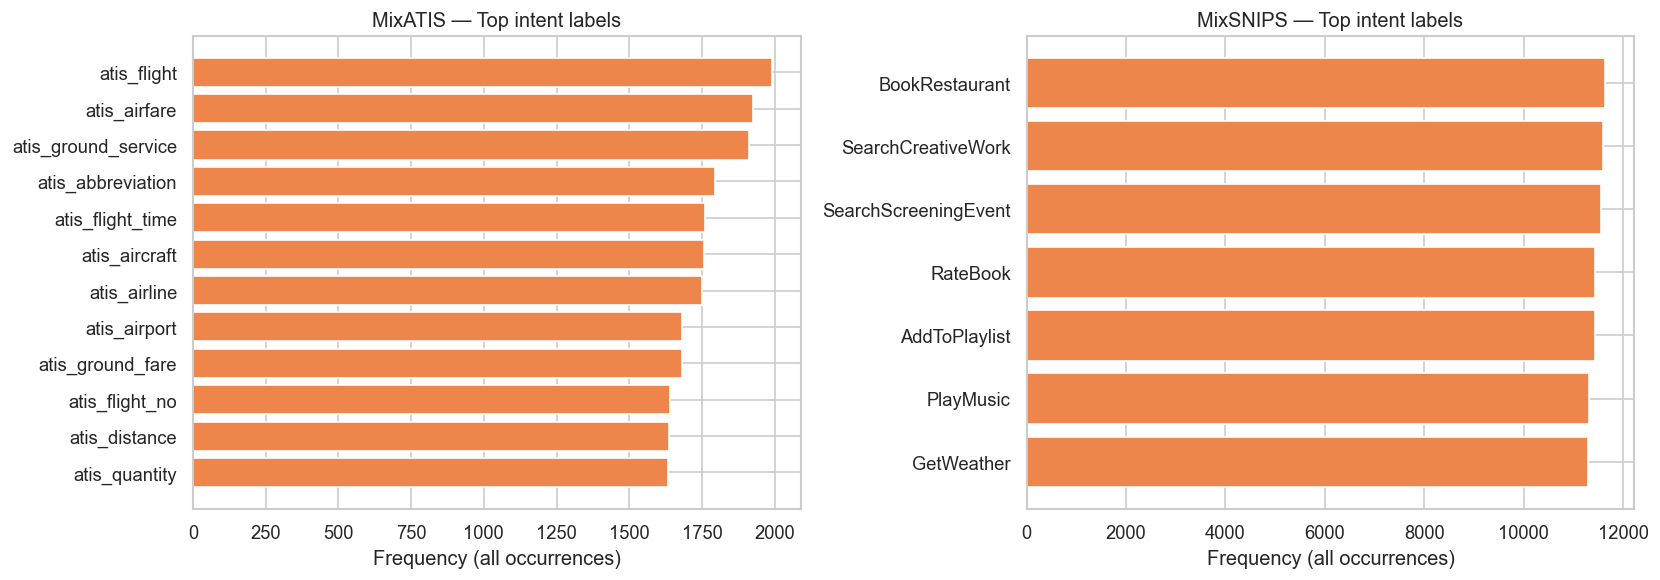

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, samples) in zip(axes, [('MixATIS', atis), ('MixSNIPS', snips)]):
    all_intents = [i for s in samples for i in s.intents]
    top = Counter(all_intents).most_common(12)
    names, counts = zip(*reversed(top))
    ax.barh(list(names), list(counts), color=sns.color_palette('muted')[1])
    ax.set_title(f'{name} — Top intent labels')
    ax.set_xlabel('Frequency (all occurrences)')

plt.tight_layout()
plt.show()

## 4. Top Slot Types

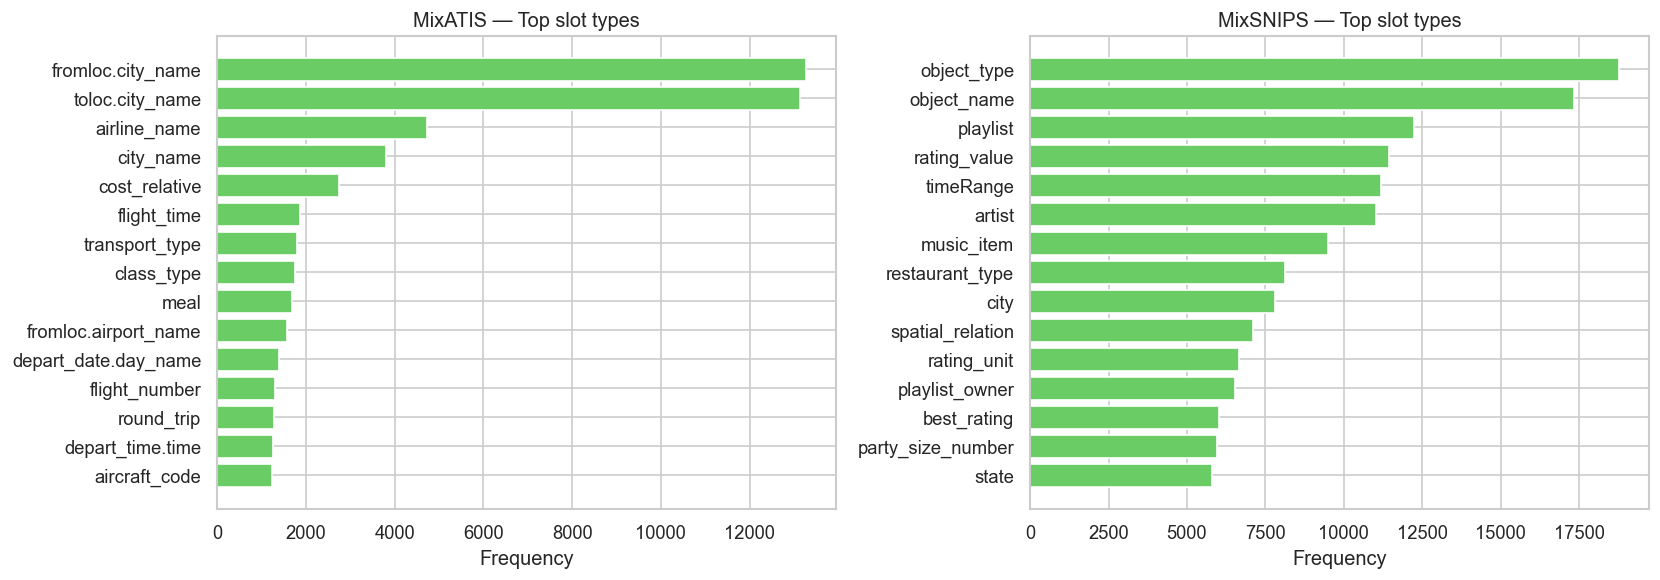

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, samples) in zip(axes, [('MixATIS', atis), ('MixSNIPS', snips)]):
    all_slots = [
        sp.slot_type
        for s in samples
        for sp in bio_to_spans([t.word for t in s.tokens], [t.bio_tag for t in s.tokens])
    ]
    top = Counter(all_slots).most_common(15)
    names, counts = zip(*reversed(top))
    ax.barh(list(names), list(counts), color=sns.color_palette('muted')[2])
    ax.set_title(f'{name} — Top slot types')
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.show()

## 5. Utterance Length Distribution

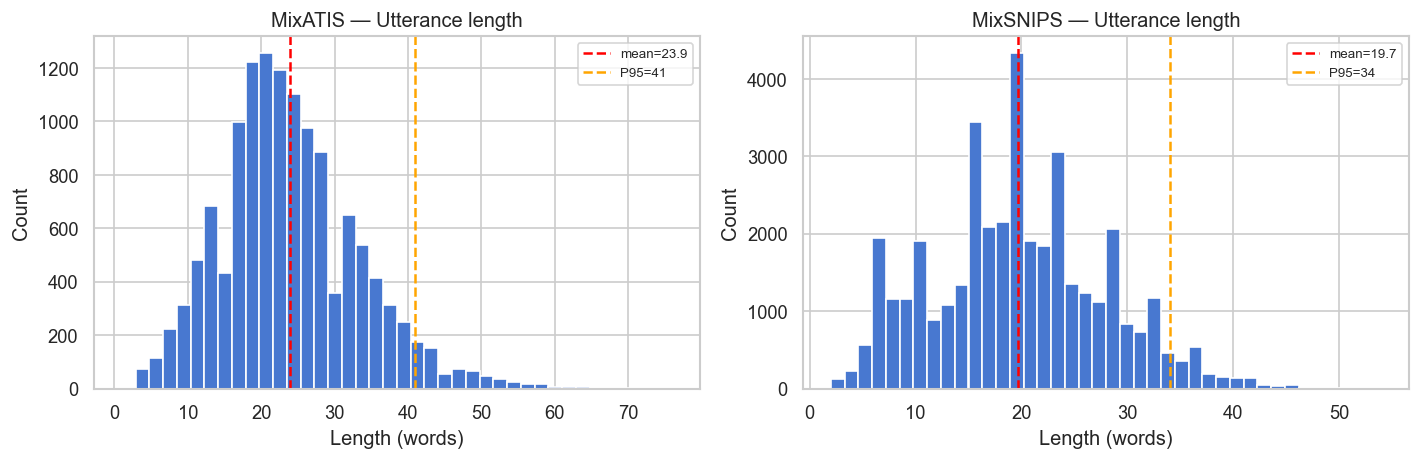

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, samples) in zip(axes, [('MixATIS', atis), ('MixSNIPS', snips)]):
    lens = [len(s.tokens) for s in samples]
    ax.hist(lens, bins=40, color=sns.color_palette('muted')[0], edgecolor='white')
    ax.axvline(np.mean(lens), color='red',    linestyle='--', label=f'mean={np.mean(lens):.1f}')
    ax.axvline(np.percentile(lens, 95), color='orange', linestyle='--',
               label=f'P95={np.percentile(lens, 95):.0f}')
    ax.set_xlabel('Length (words)')
    ax.set_ylabel('Count')
    ax.set_title(f'{name} — Utterance length')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 6. Algorithm 1 Live Demo — BERT NSP Coherence Scoring

The paper constructs **MultiATIS / MultiSNIPS** by filtering utterance pairs with BERT's
Next Sentence Prediction (NSP) head:

```
if P_NSP(u_m || u_c) > τ:   concatenate   # natural, coherent
else:                         skip           # random, incoherent
```

Below we compute `P(is_next)` for coherent vs. incoherent pairs to show the filter works.

In [10]:
import torch
from transformers import BertForNextSentencePrediction, BertTokenizerFast

print('Loading BERT NSP model...')
bert_tok = BertTokenizerFast.from_pretrained('bert-base-uncased')
bert_nsp = BertForNextSentencePrediction.from_pretrained('bert-base-uncased')
bert_nsp.eval()
print('Ready.')

def nsp_score(sent_a: str, sent_b: str) -> float:
    """Return P(IsNext) from BERT NSP for the pair (sent_a, sent_b)."""
    inp = bert_tok(sent_a, sent_b, return_tensors='pt',
                  truncation=True, max_length=128)
    with torch.no_grad():
        logits = bert_nsp(**inp).logits   # shape (1, 2): [IsNext, NotNext]
    return torch.softmax(logits, dim=-1)[0, 0].item()

Loading BERT NSP model...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Ready.


In [11]:
pairs = [
    ('play the last song by Coldplay',
     'and add it to my workout playlist',
     'coherent  (music → playlist)'),
    ('play some jazz music',
     'what is the weather in Paris tomorrow',
     'incoherent (music → weather)'),
    ('I want to book a table at an Italian restaurant',
     'for four people tonight at 8 pm',
     'coherent  (restaurant booking)'),
    ('play the latest album by Adele',
     'book a taxi to the airport for me',
     'incoherent (music → taxi)'),
    ('find me a movie playing this weekend',
     'and also look for any concerts nearby',
     'coherent  (cultural outing)'),
]

print(f'{"Sentence A":<50} {"P(coherent)":>12}  Type')
print('─' * 85)
for a, b, label in pairs:
    score = nsp_score(a, b)
    tag   = '✓' if 'coherent ' in label else '✗'
    print(f'{a[:48]:<50} {score:>12.4f}  {tag} {label}')
    print(f'  └─ {b}')
    print()

Sentence A                                          P(coherent)  Type
─────────────────────────────────────────────────────────────────────────────────────
play the last song by Coldplay                           1.0000  ✓ coherent  (music → playlist)
  └─ and add it to my workout playlist

play some jazz music                                     0.9999  ✓ incoherent (music → weather)
  └─ what is the weather in Paris tomorrow

I want to book a table at an Italian restaurant          0.9999  ✓ coherent  (restaurant booking)
  └─ for four people tonight at 8 pm

play the latest album by Adele                           0.9749  ✓ incoherent (music → taxi)
  └─ book a taxi to the airport for me

find me a movie playing this weekend                     1.0000  ✓ coherent  (cultural outing)
  └─ and also look for any concerts nearby



## 7. NSP Score Distribution on MixSNIPS (mini-sample)

Pairs sharing at least one intent : 61  mean=1.000
Pairs with different intents      : 59  mean=0.916


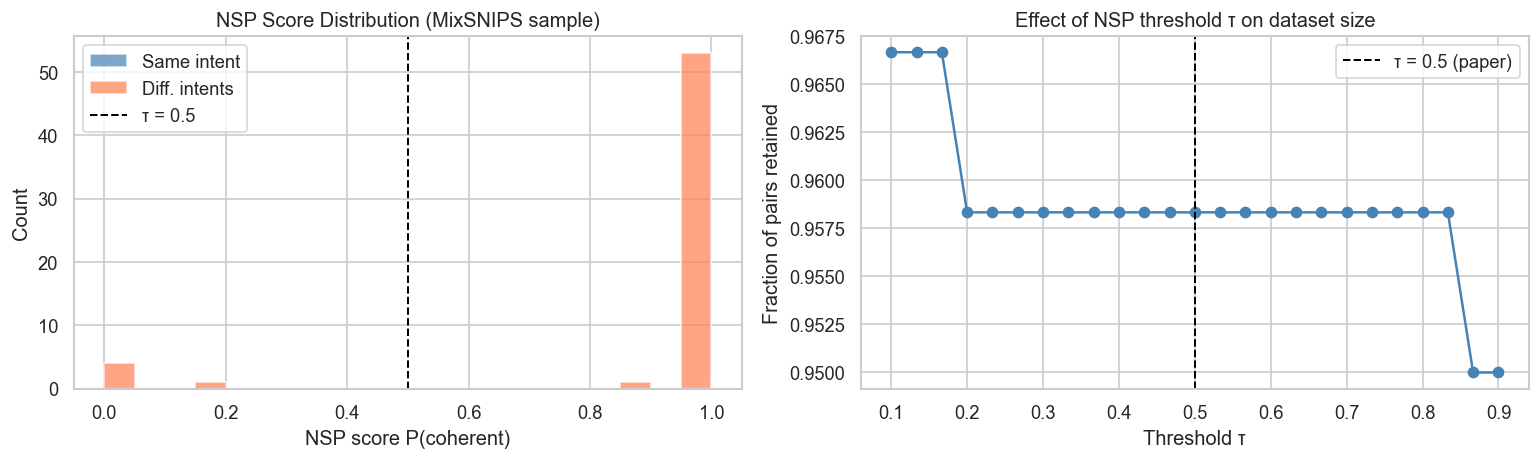

In [12]:
random.seed(42)
subset = random.sample(snips, min(240, len(snips)))

same_scores, diff_scores = [], []
for i in range(0, len(subset) - 1, 2):
    a = ' '.join(t.word for t in subset[i].tokens)
    b = ' '.join(t.word for t in subset[i + 1].tokens)
    score = nsp_score(a, b)
    if set(subset[i].intents) & set(subset[i + 1].intents):
        same_scores.append(score)
    else:
        diff_scores.append(score)

print(f'Pairs sharing at least one intent : {len(same_scores)}  mean={np.mean(same_scores):.3f}')
print(f'Pairs with different intents      : {len(diff_scores)}  mean={np.mean(diff_scores):.3f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(same_scores, bins=20, alpha=0.7, label='Same intent',  color='steelblue')
axes[0].hist(diff_scores, bins=20, alpha=0.7, label='Diff. intents', color='coral')
axes[0].axvline(0.5, color='black', linestyle='--', lw=1.2, label='τ = 0.5')
axes[0].set_xlabel('NSP score P(coherent)')
axes[0].set_ylabel('Count')
axes[0].set_title('NSP Score Distribution (MixSNIPS sample)')
axes[0].legend()

all_scores = same_scores + diff_scores
thresholds = np.linspace(0.1, 0.9, 25)
retain_rate = [np.mean(np.array(all_scores) > t) for t in thresholds]
axes[1].plot(thresholds, retain_rate, marker='o', color='steelblue')
axes[1].axvline(0.5, color='black', linestyle='--', lw=1.2, label='τ = 0.5 (paper)')
axes[1].set_xlabel('Threshold τ')
axes[1].set_ylabel('Fraction of pairs retained')
axes[1].set_title('Effect of NSP threshold τ on dataset size')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Full Dataset Statistics Summary

In [13]:
import pandas as pd

rows = []
for ds_name, base in [('MixATIS', '../data/raw/mixatis'), ('MixSNIPS', '../data/raw/mixsnips')]:
    for split in ['train', 'dev', 'test']:
        p = Path(base) / f'{split}.txt'
        if not p.exists():
            continue
        samps = load_raw_dataset(p)
        n_multi  = sum(1 for s in samps if len(s.intents) > 1)
        avg_toks = np.mean([len(s.tokens) for s in samps])
        avg_slots = np.mean([
            len(bio_to_spans([t.word for t in s.tokens], [t.bio_tag for t in s.tokens]))
            for s in samps
        ])
        rows.append({
            'Dataset': ds_name, 'Split': split, 'Samples': len(samps),
            'Multi-intent (%)': f'{100 * n_multi / len(samps):.1f}',
            'Avg tokens': f'{avg_toks:.1f}',
            'Avg slots/utt': f'{avg_slots:.2f}',
        })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

 Dataset Split  Samples Multi-intent (%) Avg tokens Avg slots/utt
 MixATIS train    13162             91.5       23.9          5.20
 MixATIS   dev      759             86.2       21.4          4.93
 MixATIS  test      828             82.7       20.4          4.54
MixSNIPS train    39776             79.2       19.7          5.23
MixSNIPS   dev     2198             79.6       20.1          5.19
MixSNIPS  test     2199             79.5       19.8          5.22
